# Import libraries

In [1]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Load the dataset


In [2]:
! rm -rf Potatoes

In [3]:
import kagglehub


path1 = kagglehub.dataset_download("faysalmiah1721758/potato-dataset")

print("Path to dataset files:", path1)

path2 = kagglehub.dataset_download("nirmalsankalana/potato-leaf-healthy-and-late-blight")

print("Path to dataset files:", path2)

Path to dataset files: /kaggle/input/datasets/faysalmiah1721758/potato-dataset
Path to dataset files: /kaggle/input/datasets/nirmalsankalana/potato-leaf-healthy-and-late-blight


# Create path to save dataset

In [4]:

try:
    os.mkdir('/kaggle/working/Potatoes')
except FileExistsError:
    print("Directory Already Exist")
    

try:
     os.mkdir('/kaggle/working/Potatoes/Early_Blight')
     os.mkdir('/kaggle/working/Potatoes/Healthy')
     os.mkdir('/kaggle/working/Potatoes/train')
     os.mkdir('/kaggle/working/Potatoes/test')
     os.mkdir('/kaggle/working/Potatoes/valid')
     os.mkdir('/kaggle/working/Potatoes/train/Healthy')
     os.mkdir('/kaggle/working/Potatoes/test/Healthy')
     os.mkdir('/kaggle/working/Potatoes/valid/Healthy')
     os.mkdir('/kaggle/working/Potatoes/train/Early_Blight')
     os.mkdir('/kaggle/working/Potatoes/test/Early_Blight')
     os.mkdir('/kaggle/working/Potatoes/valid/Early_Blight')
except FileExistsError:
    print("Directories Already Exist")
    

# Move datasets from kaggle to local directory.

In [5]:
import shutil


shutil.copytree(f'{path1}/Potato___healthy','/kaggle/working/Potatoes/Healthy' ,dirs_exist_ok=True)
shutil.copytree(f'{path2}/Healthy', '/kaggle/working/Potatoes/Healthy', dirs_exist_ok=True)
shutil.copytree(f'{path1}/Potato___Early_blight','/kaggle/working/Potatoes/Early_Blight' ,dirs_exist_ok=True)


'/kaggle/working/Potatoes/Early_Blight'

In [6]:
SRC_DIR =  '/kaggle/working/Potatoes/Early_Blight'

# get all image files
files = list(Path(SRC_DIR).glob("*.jpg")) + list(Path(SRC_DIR).glob("*.png")) +  list(Path(SRC_DIR).glob("*.JPG"))

# to_train = round(len(files) * 0.8) 
files_to_train = files[:450]

files_to_test = files[450:475]

files_to_valid = files[475:500]

for f in files_to_train:
    shutil.copy(f, '/kaggle/working/Potatoes/train/Early_Blight')

for f in files_to_test:
    shutil.copy(f, '/kaggle/working/Potatoes/test/Early_Blight')

for f in files_to_valid:
    shutil.copy(f, '/kaggle/working/Potatoes/valid/Early_Blight')

print('Completed')

Completed


In [7]:
SRC_DIR =  '/kaggle/working/Potatoes/Healthy'

# get all image files
files = list(Path(SRC_DIR).glob("*.jpg")) + list(Path(SRC_DIR).glob("*.png")) +  list(Path(SRC_DIR).glob("*.JPG"))

# to_train = round(len(files) * 0.8) 
files_to_train = files[:450]

files_to_test = files[450:475]

files_to_valid = files[475:500]

for f in files_to_train:
    shutil.copy(f, '/kaggle/working/Potatoes/train/Healthy')

for f in files_to_test:
    shutil.copy(f, '/kaggle/working/Potatoes/test/Healthy')

for f in files_to_valid:
    shutil.copy(f, '/kaggle/working/Potatoes/valid/Healthy')

print('Completed')

Completed


# Set random seeds

In [8]:
SEED = 30
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Set global hyperparameters.

In [9]:
DATASET_DIR = '/kaggle/working/Potatoes'
IMG_SIZE = (224, 224)
BATCH_SIZE = 30
EPOCHS = 50
LR = 1e-4

# Load the training dataset 

In [10]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/train',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle= True,
)

Found 900 files belonging to 2 classes.


I0000 00:00:1785287092.327599      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


# Load the test dataset

In [11]:
test_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/test',
    seed=SEED,
    image_size=IMG_SIZE,
    shuffle= False,
    batch_size= BATCH_SIZE,
)

Found 50 files belonging to 2 classes.


# Load the validation dataset

In [12]:
valid_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{DATASET_DIR}/valid',
    seed=SEED,
    image_size=IMG_SIZE,
    shuffle= False,
    batch_size= BATCH_SIZE,
)

Found 50 files belonging to 2 classes.


# Get class names and number of classes

In [13]:
class_names = train_dataset.class_names
num_classes= len(class_names)
print(f'Classes ({num_classes}): {class_names}')

Classes (2): ['Early_Blight', 'Healthy']


# Visualise dataset samples

In [14]:
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

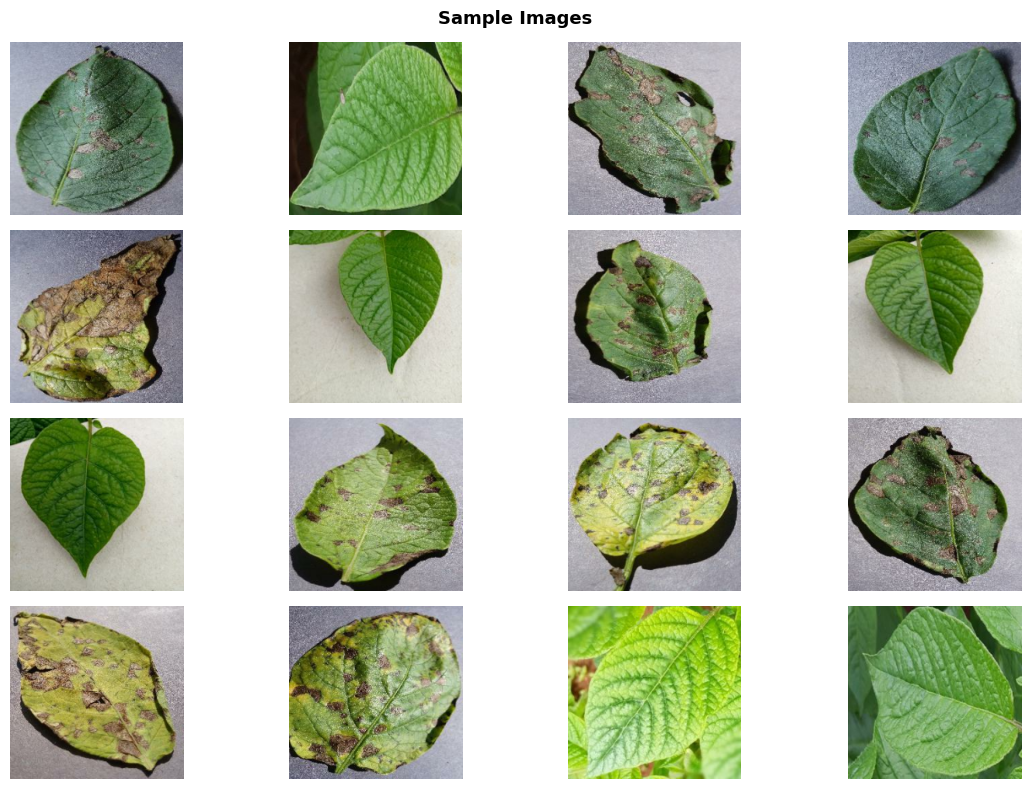

In [15]:
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.axis('off')
plt.suptitle('Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample.png', dpi=120, bbox_inches='tight')
plt.show()

# Optimise the data pipeline.

In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = (train_dataset.cache().shuffle(300).prefetch(buffer_size=AUTOTUNE))
valid_dataset = (valid_dataset.cache().prefetch(buffer_size=AUTOTUNE))
test_dataset = (test_dataset.cache().prefetch(buffer_size=AUTOTUNE))

 # Define the data augmentation pipeline.

In [17]:

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.3),       
    tf.keras.layers.RandomZoom(0.2),           
], name= 'data_augumentation')

# Visualise augmentation effects on one image

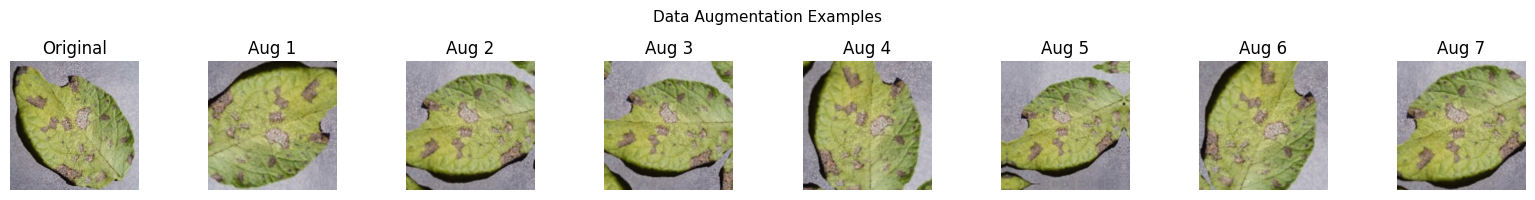

In [18]:
for images, _ in train_dataset.take(1):
    sample = images[0:1] 
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample,training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

plt.suptitle('Data Augmentation Examples', fontsize=11)
plt.tight_layout()
plt.show()

# Define shared callbacks and utilities.

In [19]:
os.makedirs('models', exist_ok=True)
def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [ tf.keras.callbacks.ModelCheckpoint(
        filepath=f'models/{name}_best.keras',
        monitor='val_accuracy', save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8,
        restore_best_weights=True, verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.3,
        patience=4, min_lr=1e-7, verbose=1
        ),
        ]
def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc= history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2,linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


#  Build the Transfer Learning Model (MobileNetV3Small)

In [20]:
INPUT_SHAPE = (224, 224, 3)
OUTPUTS = num_classes

def build_transfer_model(input_shape, augmentation):
   
    
    base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
    preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
    model_name= 'mobilenetv3small_transfer'
    
    
    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model: {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')
    
    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]
    x = base_model(x, training=False)
    # frozen inference mode
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(OUTPUTS, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs, name=model_name), base_model
    
tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation)
tl_model.summary()

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model: MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augumentation (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

# Compile Transfer learning model 

In [21]:

tl_model.compile(
optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
loss='sparse_categorical_crossentropy',
metrics=['accuracy'],
)



# Train the model.

In [22]:
tl_history = tl_model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.7778 - loss: 0.4695 - val_accuracy: 0.9200 - val_loss: 0.3136 - learning_rate: 1.0000e-04
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9522 - loss: 0.1827 - val_accuracy: 1.0000 - val_loss: 0.2019 - learning_rate: 1.0000e-04
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9767 - loss: 0.1135 - val_accuracy: 1.0000 - val_loss: 0.1180 - learning_rate: 1.0000e-04
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9844 - loss: 0.0828 - val_accuracy: 1.0000 - val_loss: 0.1058 - learning_rate: 1.0000e-04
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9922 - loss: 0.0600 - val_accuracy: 1.0000 - val_loss: 0.0737 - learning_rate: 1.0000e-04
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9922 - loss: 0.0500 - val_accuracy: 1.0000 - val_loss: 0.0721 - learning_rate: 1.0000e-04
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.994

# Evaluate the Transfer Learning Model on validation dataset

MobileNetV3 TL -> val_loss: 0.0165
MobileNetV3 TL -> val_accuracy: 1.0000


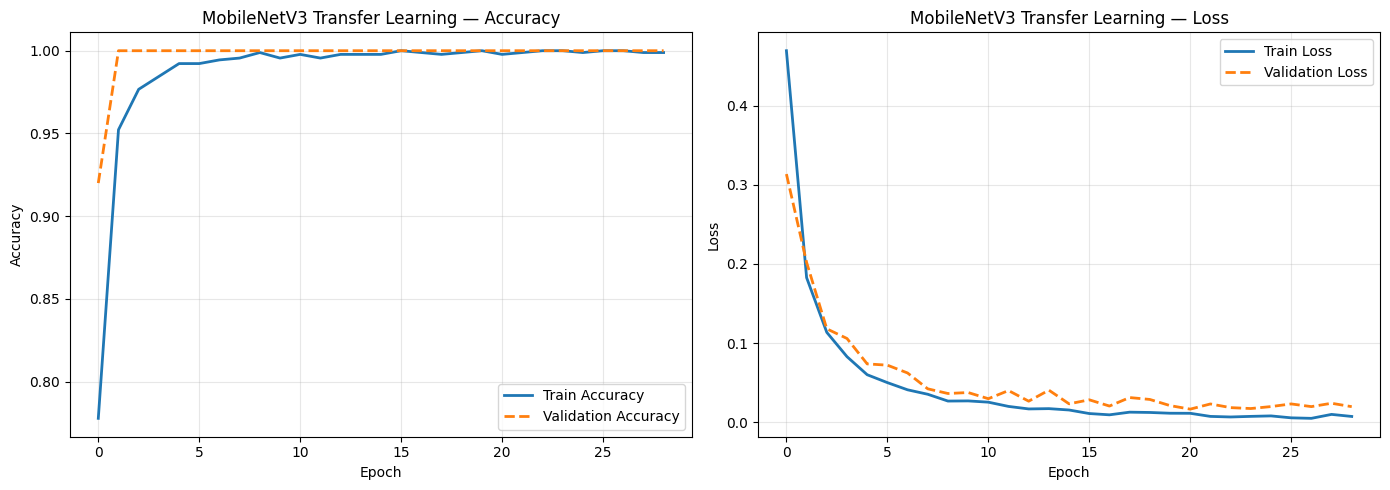

In [23]:
tl_val_loss, tl_val_acc = tl_model.evaluate(valid_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate the Transfer Learning Model on test dataset

MobileNetV3 TL -> val_loss: 0.0211
MobileNetV3 TL -> val_accuracy: 1.0000


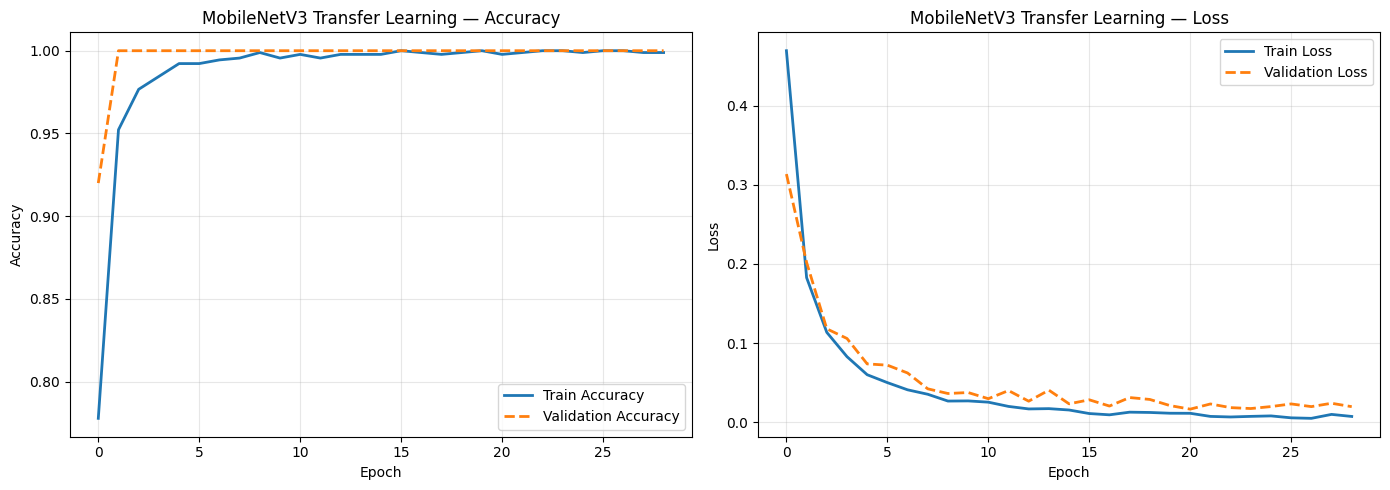

In [24]:
tl_test_loss, tl_test_acc = tl_model.evaluate(test_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_test_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_test_acc:.4f}')
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate Model

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
[[25  0]
 [ 0 25]]


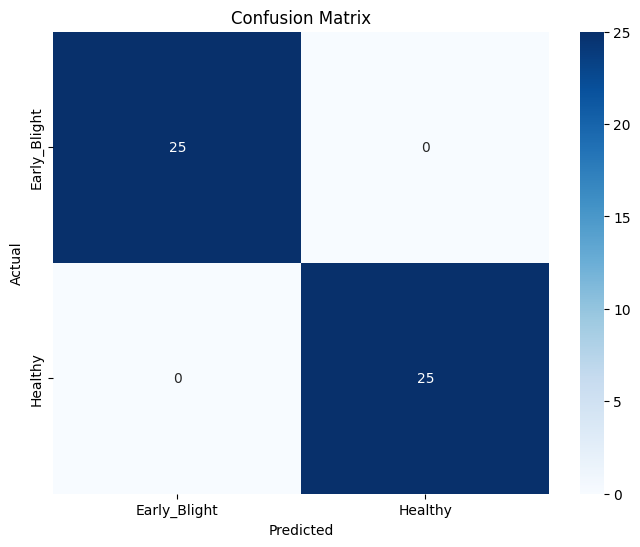

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [25]:
y_pred_probs = tl_model.predict(valid_dataset)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = np.concatenate([y for x, y in valid_dataset], axis=0)

y_true = y_true.flatten()
y_pred = y_pred.flatten()

cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels= class_names, 
            yticklabels=class_names) 
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Optional: Print detailed report (Precision, Recall, F1-Score)
print(classification_report(y_true, y_pred))

# Predict on a new image.

In [41]:
img_path = '/kaggle/input/datasets/faysalmiah1721758/potato-dataset/Potato___Early_blight/002a55fb-7a3d-4a3a-aca8-ce2d5ebc6925___RS_Early.B 8170.JPG'

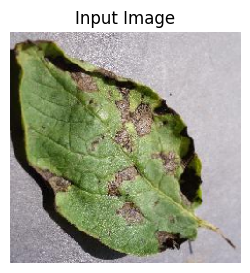

 Early_Blight


In [42]:
img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) 
    
plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.axis('off')
plt.title('Input Image')
plt.show()
    
prob = tl_model.predict(img_array, verbose=0)[0][0]
label = class_names[int(prob <= 0.5)]
print(f' {label}')

In [28]:
class_names[int(False)]

'Early_Blight'

# Save Models 

In [29]:
os.makedirs('models', exist_ok=True)
tl_model.save('models/mobilenetv3_transfer.keras')
print('Models saved:')
print(' models/mobilenetv3_transfer.keras')

Models saved:
 models/mobilenetv3_transfer.keras
